# Medicine Stockout Prediction - Week 1

This is my Week 1 work for the group project. I looked at the medicine stock data and did some basic exploring before we start building models next week.

Dataset used: medicine_stockout_prediction_AUGMENTED.csv (5653 rows, 19 columns)


## 1. What are we trying to do?

Health centers sometimes run out of medicine (this is called a "stockout"). We want to build a model that can predict if a medicine will run out **next month**, using the stock data from this month and past months.

**Inputs (things we know already):** how much stock was there at start of month, how much came in, how much was used, how much is left, and some numbers based on past months.

**Output (what we want to predict):** stockout_next_month - 1 if it will run out next month, 0 if not.

This is a classification problem (yes/no answer).


## 2. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


## 3. Load the data

In [2]:
df = pd.read_csv("medicine_stockout_prediction.csv")
print(df.shape)
df.head()


(5653, 19)


,hf_pk,productID,name1,date,openBalance,received,consumption,closeBalance,Stock_Cover,Days_of_Stock_Remaining,Previous_Month_Consumption,Consumption_Change,Rolling_3_Month_Consumption,Previous_Month_Received,Rolling_3_Month_Received,Previous_Month_OpenBalance,Previous_Month_CloseBalance,Previous_Month_Stockout,stockout_next_month
0,10166,20,"Water for Injection 10ml, Inj, Amp",2019-10-01,77,0,40,37,1.925000,57.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,10166,28,"Benzyl Benzoate 25%, Emulsion, 100ml, Bot",2019-10-01,0,0,200,0,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,10166,34,"Folic Acid 5mg, Tab",2019-10-01,1324,0,372,952,3.559140,106.774193,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,10166,35,"Oxytocin 10IU, Inj, Amp",2019-10-01,116,0,17,99,6.823529,204.705882,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,10166,38,"Albendazole 400mg, Tab",2019-10-01,0,0,16,0,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5653 entries, 0 to 5652
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   hf_pk                        5653 non-null   int64  
 1   productID                    5653 non-null   int64  
 2   name1                        5653 non-null   str    
 3   date                         5653 non-null   str    
 4   openBalance                  5653 non-null   int64  
 5   received                     5653 non-null   int64  
 6   consumption                  5653 non-null   int64  
 7   closeBalance                 5653 non-null   int64  
 8   Stock_Cover                  5148 non-null   float64
 9   Days_of_Stock_Remaining      5148 non-null   float64
 10  Previous_Month_Consumption   5501 non-null   float64
 11  Consumption_Change           5501 non-null   float64
 12  Rolling_3_Month_Consumption  5501 non-null   float64
 13  Previous_Month_Received      

In [10]:
df.describe()


,hf_pk,productID,openBalance,received,consumption,closeBalance,Stock_Cover,Days_of_Stock_Remaining,Previous_Month_Consumption,Consumption_Change,Rolling_3_Month_Consumption,Previous_Month_Received,Rolling_3_Month_Received,Previous_Month_OpenBalance,Previous_Month_CloseBalance,Previous_Month_Stockout,stockout_next_month
count,5653.000000,5653.000000,5653.000000,5653.000000,5653.000000,5653.000000,5148.000000,5148.000000,5501.000000,5501.000000,5501.000000,5501.000000,5501.000000,5501.000000,5501.000000,5501.000000,5653.000000
mean,10017.048824,35.014329,435.193526,242.918273,255.197771,435.591191,5.329528,159.885852,255.895655,-1.495728,255.843180,246.475550,242.424286,434.352118,437.721687,0.165788,0.165045
std,41.472474,10.578288,974.563641,938.901326,510.458077,980.335289,51.782249,1553.467459,509.294781,342.792382,467.899244,947.967624,528.872831,963.655726,981.155313,0.371924,0.371254
min,10001.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3180.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10003.000000,22.000000,4.000000,0.000000,4.000000,4.000000,1.000000,30.000000,4.000000,-24.000000,4.666667,0.000000,0.000000,4.000000,4.000000,0.000000,0.000000
50%,10006.000000,35.000000,51.000000,0.000000,50.000000,50.000000,1.599435,47.983051,50.000000,0.000000,58.000000,0.000000,27.666667,51.000000,51.000000,0.000000,0.000000
75%,10009.000000,43.000000,311.000000,7.000000,204.000000,311.000000,3.000000,90.000000,205.000000,19.000000,230.000000,7.000000,180.000000,314.000000,312.000000,0.000000,0.000000
max,10166.000000,52.000000,11942.000000,12438.000000,4450.000000,11942.000000,2117.000000,63510.000000,4450.000000,4450.000000,3449.000000,12438.000000,4968.333333,11106.000000,11942.000000,1.000000,1.000000


## 4. Data dictionary (what each column means)



In [11]:
print("Number of facilities:", df['hf_pk'].nunique())
print(df['hf_pk'].value_counts())
print()
print("Number of medicines:", df['name1'].nunique())
print(df['name1'].unique())


Number of facilities: 11
hf_pk
10005    600
10002    576
10008    572
10007    564
10003    555
10009    516
10010    511
10006    490
10001    448
10004    416
10166    405
Name: count, dtype: int64

Number of medicines: 16
<StringArray>
[                       'Water for Injection 10ml, Inj, Amp',
                 'Benzyl Benzoate 25%, Emulsion, 100ml, Bot',
                                       'Folic Acid 5mg, Tab',
                                   'Oxytocin 10IU, Inj, Amp',
                                    'Albendazole 400mg, Tab',
                      'Oral Rehydration Salts (ORS), Sachet',
                      'Zinc Sulphate 20mg, Dispersible, Tab',
                    'Paracetamol (Acetaminophen) 500mg, Tab',
                        'Povidone Iodine 10%, Solution, Bot',
                                     'Methyldopa 250mg, Tab',
                'Ampicillin 500mg, Pdr for IM/IV, Inj, Vial',
       'Paracetamol (Acetaminophen) 250mg, Dispersible, Tab',
                 

## 5. Checking the target column

Before building a model we should see how many rows say "stockout" vs "no stockout".

stockout_next_month
0    4720
1     933
Name: count, dtype: int64
<bound method IndexOpsMixin.value_counts of 0       0
1       1
2       0
3       0
4       0
       ..
5648    0
5649    0
5650    0
5651    0
5652    0
Name: stockout_next_month, Length: 5653, dtype: int64>


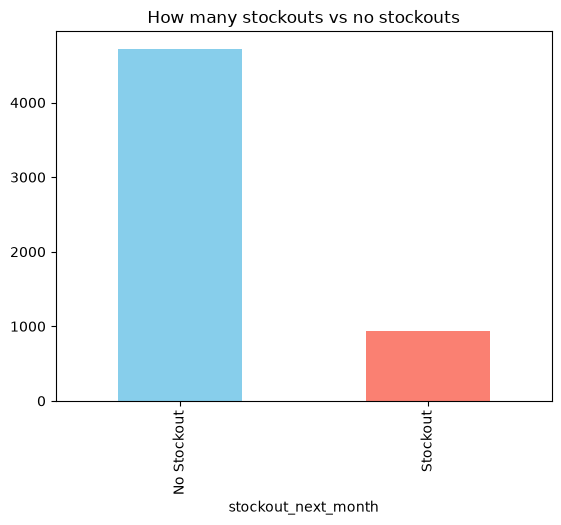

In [3]:
print(df['stockout_next_month'].value_counts())
print(df['stockout_next_month'].value_counts)

df['stockout_next_month'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.xticks([0,1], ['No Stockout','Stockout'])
plt.title("How many stockouts vs no stockouts")
plt.show()


So about 17% of the rows are stockouts and 83% are not. This means the data is a bit imbalanced - there are way more "no stockout" cases than "stockout" cases. 

## 6. Missing values

In [4]:
missing = df.isna().sum()
missing[missing > 0]


Stock_Cover                    505
Days_of_Stock_Remaining        505
Previous_Month_Consumption     152
Consumption_Change             152
Rolling_3_Month_Consumption    152
Previous_Month_Received        152
Rolling_3_Month_Received       152
Previous_Month_OpenBalance     152
Previous_Month_CloseBalance    152
Previous_Month_Stockout        152
dtype: int64

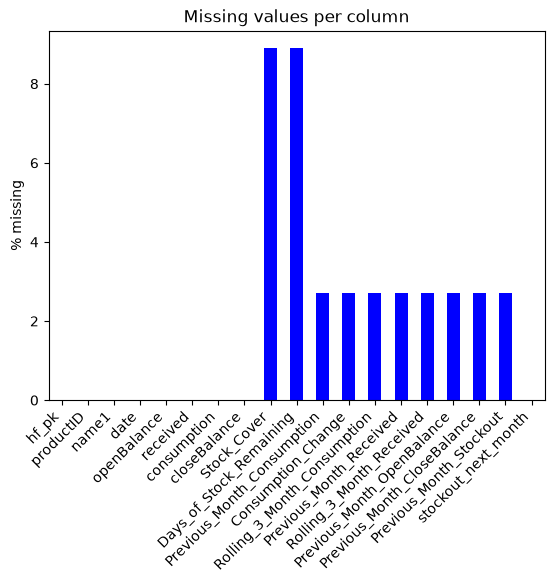

In [5]:
(df.isna().mean()*100).round(1).plot(kind='bar',  color='blue')
plt.ylabel("% missing")
plt.title("Missing values per column")
plt.xticks(rotation=45, ha='right')
plt.show()


Some columns have missing values. So we are going to drop them since their not many as we are going  to train our model



## 7. Looking at the numbers (distributions)

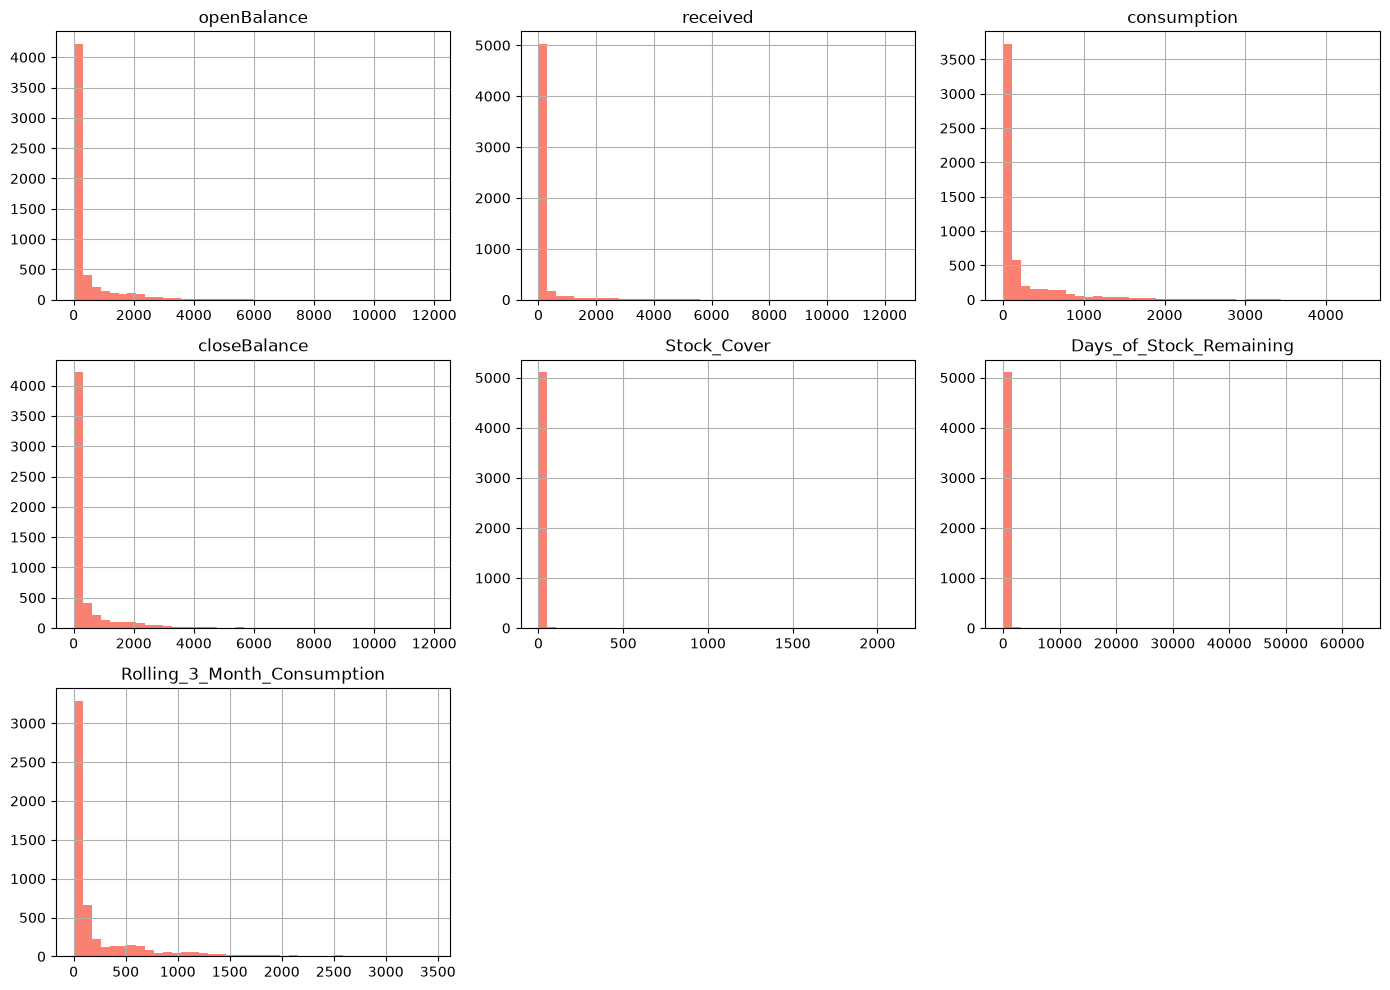

In [6]:
cols_to_check = ['openBalance', 'received', 'consumption', 'closeBalance',
                  'Stock_Cover', 'Days_of_Stock_Remaining', 'Rolling_3_Month_Consumption']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cols_to_check):
    df[col].dropna().hist(bins=40, ax=axes[i], color='salmon')
    axes[i].set_title(col)
for j in range(len(cols_to_check), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


Most of these numbers are lots of small values and a few really big ones. This makes sense because some medicines (like Paracetamol) get used a lot more than others (like Oxytocin). We might need to scale these numbers before putting them in a model.

In [ ]:
APPLYING LOG1 FOR NORMALIZING OUTLIERS

In [20]:
cols_to_check = df.select_dtypes(include=np.number).columns

df[cols_to_check] = np.log1p(df[cols_to_check])

## 8. Checking for outliers

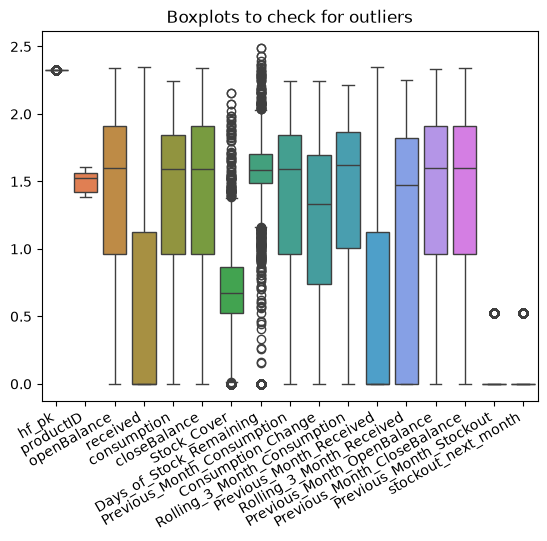

In [21]:
plt.figure()
sns.boxplot(data=df[cols_to_check])
plt.xticks(rotation=30, ha='right')
plt.title("Boxplots to check for outliers")
plt.show()


In [8]:
def outlier_percent(col):
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    return round(((s < low) | (s > high)).mean()*100, 2)

for c in cols_to_check:
    print(c, ":", outlier_percent(c), "% outliers")


openBalance : 15.53 % outliers
received : 20.96 % outliers
consumption : 16.42 % outliers
closeBalance : 15.53 % outliers
Stock_Cover : 7.3 % outliers
Days_of_Stock_Remaining : 7.3 % outliers
Rolling_3_Month_Consumption : 15.27 % outliers


There are a few outliers but they mostly come from the medicines that are used in bigger amounts (like Zinc Sulphate). These are not mistakes in the data, just normal high numbers for those medicines. So we probably won't remove them.

## 9. Does stock cover relate to stockouts?

C:\Users\Administrator\AppData\Local\Temp\ipykernel_15068\2194388151.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_xticklabels(['No Stockout','Stockout'])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_15068\2194388151.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[1].set_xticklabels(['No stockout last month','Stockout last month'])


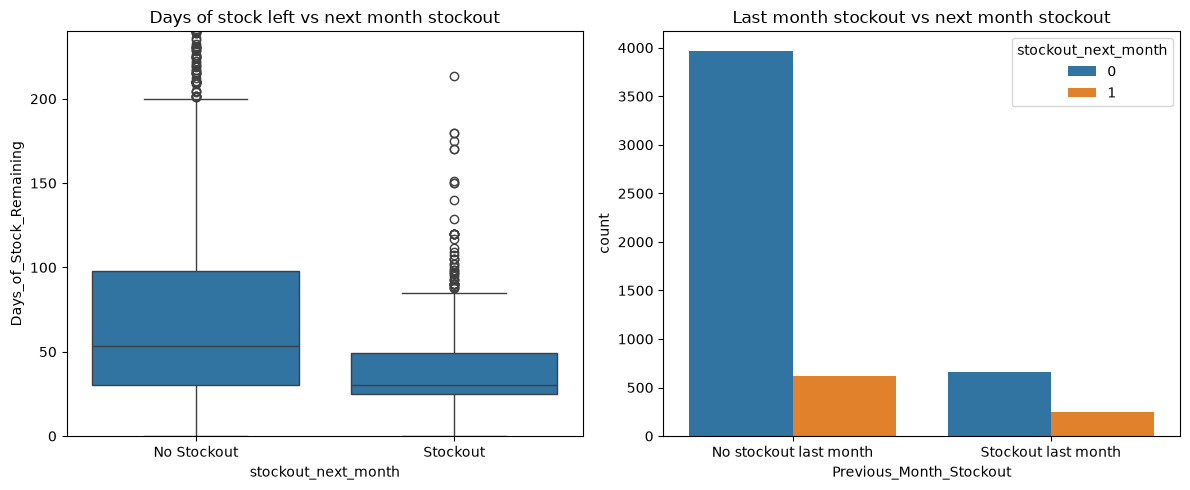

In [9]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(data=df, x='stockout_next_month', y='Days_of_Stock_Remaining', ax=ax[0])
ax[0].set_ylim(0, df['Days_of_Stock_Remaining'].quantile(0.95))
ax[0].set_xticklabels(['No Stockout','Stockout'])
ax[0].set_title("Days of stock left vs next month stockout")

sns.countplot(data=df, x='Previous_Month_Stockout', hue='stockout_next_month', ax=ax[1])
ax[1].set_xticklabels(['No stockout last month','Stockout last month'])
ax[1].set_title("Last month stockout vs next month stockout")

plt.tight_layout()
plt.show()


Looks like when there are fewer days of stock left, a stockout next month is more likely. Also if a stockout happened last month, it's more likely to happen again. This makes sense and gives us a good sign these columns will actually help the model.

## 10. Correlation heatmap

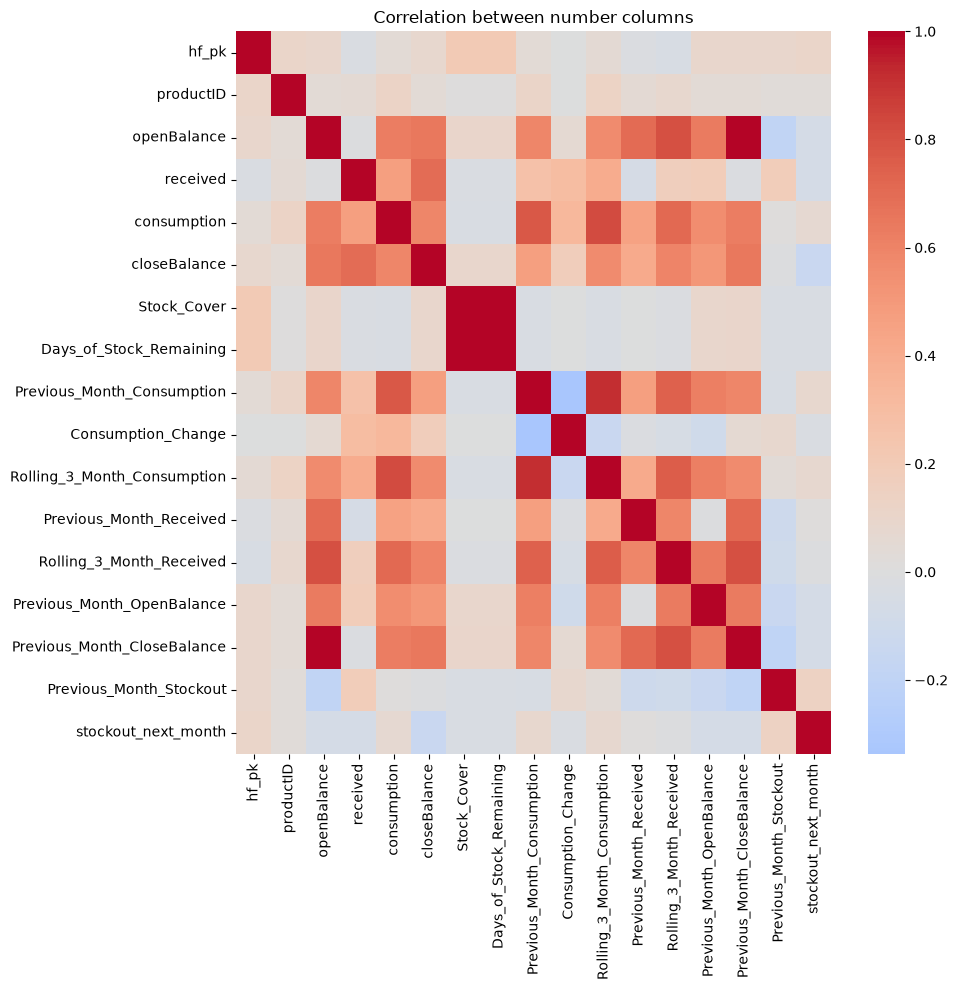

In [12]:
plt.figure(figsize=(10,10))
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation between number columns")
plt.tight_layout()
plt.show()


Stock_Cover and Days_of_Stock_Remaining are basically the same thing just multiplied by 30, so we probably only need one of them in the model, not both.

## 11. Quick look at facilities

In [13]:
facility_rate = df.groupby('hf_pk')['stockout_next_month'].mean().sort_values(ascending=True)
facility_rate


hf_pk
10009    0.083333
10003    0.099099
10008    0.108392
10007    0.113475
10004    0.127404
10001    0.162946
10010    0.174168
10002    0.175347
10005    0.243333
10006    0.246939
10166    0.311111
Name: stockout_next_month, dtype: float64

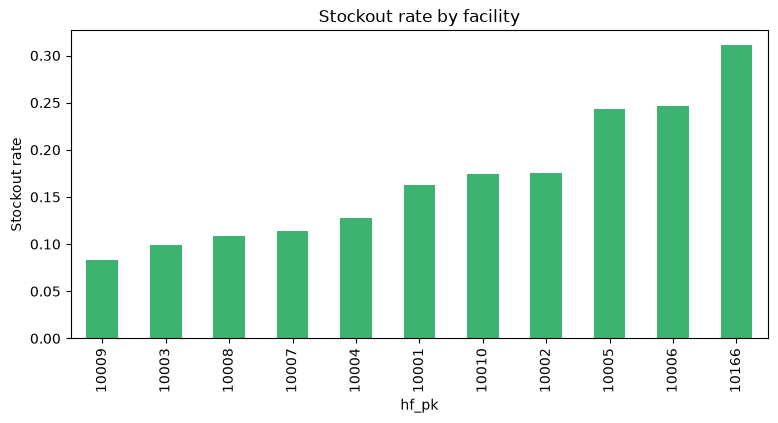

In [14]:
facility_rate.plot(kind='bar', color='mediumseagreen', figsize=(9,4))
plt.ylabel("Stockout rate")
plt.title("Stockout rate by facility")
plt.show()


Some facilities have way more stockouts than others. That's expected since 10 of these facilities are made-up data we generated to have more rows to train on, and only one facility (10166) is the real one.

In [3]:
df_clean = df.dropna().reset_index(drop=True)
print("Rows before:", len(df), "| Rows after dropping NaNs:", len(df_clean))
df_clean.head()


NameError: name 'df' is not defined

In [1]:
Feature Selection

- `openBalance`, `received`, `consumption`, `closeBalance`
- `Stock_Cover`
- `Previous_Month_Consumption`, `Consumption_Change`, `Rolling_3_Month_Consumption`
- `Previous_Month_Received`, `Rolling_3_Month_Received`
- `Previous_Month_OpenBalance`, `Previous_Month_CloseBalance`
- `Previous_Month_Stockout`

`Days_of_Stock_Remaining` is used as the target for the regression model, and `stockout_next_month` as the target for the classification models.

SyntaxError: invalid syntax (4289802158.py, line 1)

In [2]:
feature_cols = [
    'openBalance', 'received', 'consumption', 'closeBalance',
    'Stock_Cover', 'Previous_Month_Consumption', 'Consumption_Change',
    'Rolling_3_Month_Consumption', 'Previous_Month_Received',
    'Rolling_3_Month_Received', 'Previous_Month_OpenBalance',
    'Previous_Month_CloseBalance', 'Previous_Month_Stockout'
]

X = df_clean[feature_cols]
print("Feature matrix shape:", X.shape)
X.head(20)


NameError: name 'df_clean' is not defined